# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

Explore the dataset with key visualizations to understand distributions, class balance, and relationships with the target.

In [4]:
# DATA EXPLORATION
# This section creates key visualizations to understand the target balance,
# numeric feature behavior, category-level recommendation rates, and text characteristics.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Confirm expected columns exist and quickly inspect missingness.

In [5]:
# Quick sanity checks: columns and missingness

print("Columns:", list(df.columns))

missing_rate = df.isna().mean().sort_values(ascending=False)
print("\nTop missing rates:")
print(missing_rate.head(15))

print("\nTarget distribution (Recommended IND):")
print(df["Recommended IND"].value_counts())

Columns: ['Clothing ID', 'Age', 'Title', 'Review Text', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name', 'Recommended IND']

Top missing rates:
Clothing ID                0.0
Age                        0.0
Title                      0.0
Review Text                0.0
Positive Feedback Count    0.0
Division Name              0.0
Department Name            0.0
Class Name                 0.0
Recommended IND            0.0
dtype: float64

Target distribution (Recommended IND):
Recommended IND
1    15053
0     3389
Name: count, dtype: int64


Plot the class balance of the recommendation label.

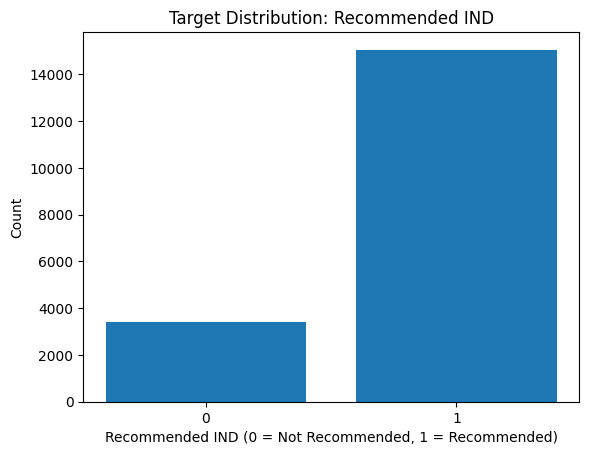

Class ratio (%):
Recommended IND
0    18.38
1    81.62
Name: count, dtype: float64


In [6]:
# Plot target distribution

target_counts = df["Recommended IND"].value_counts().sort_index()

plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target Distribution: Recommended IND")
plt.xlabel("Recommended IND (0 = Not Recommended, 1 = Recommended)")
plt.ylabel("Count")
plt.show()

print("Class ratio (%):")
print((target_counts / target_counts.sum() * 100).round(2))

From the visualization, it is clear that the dataset is significantly imbalanced. Approximately 81.6% of the reviews recommend the product, while only 18.4% of the reviews do not recommend it.From a machine learning perspective, class imbalance is an important factor to consider. A model trained on such data may become biased toward predicting the majority class (recommended), which can lead to misleading accuracy scores. Therefore, evaluation metrics such as precision, recall, and F1-score are more informative than accuracy alone when assessing model performance.

Inspect customer age distribution overall and by recommendation outcome.

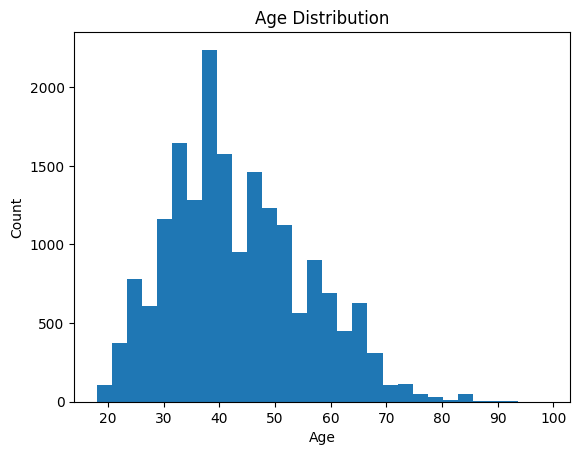

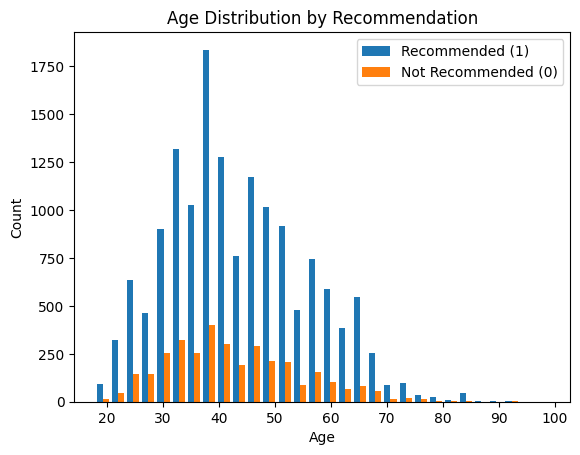

Age summary by target:


,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,42.437592,11.694862,19.0,34.0,41.0,50.0,91.0
1,15053.0,43.596625,12.357405,18.0,35.0,42.0,52.0,99.0


In [7]:
# Age distribution overall

plt.figure()
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Age distribution by target
recommended_age = df.loc[df["Recommended IND"] == 1, "Age"].dropna()
not_recommended_age = df.loc[df["Recommended IND"] == 0, "Age"].dropna()

plt.figure()
plt.hist([recommended_age, not_recommended_age], bins=30, label=["Recommended (1)", "Not Recommended (0)"])
plt.title("Age Distribution by Recommendation")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Age summary by target:")
display(df.groupby("Recommended IND")["Age"].describe())

The first histogram shows the overall age distribution of customers who wrote reviews. The distribution appears to be approximately centered between ages 30 and 50, with the highest concentration around the late 30s and early 40s. This indicates that the majority of reviewers belong to a middle-aged customer segment.Overall, these findings suggest that while age is an important demographic feature of the dataset, it may provide limited predictive power compared to other features such as review text or product category.

Compare how “Positive Feedback Count” behaves for recommended vs not recommended.

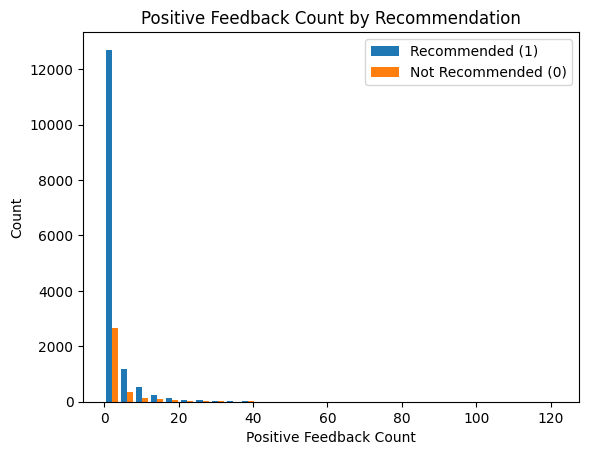

Positive Feedback Count summary by target:


,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,3.428740,6.698298,0.0,0.0,1.0,4.0,108.0
1,15053.0,2.532851,5.745748,0.0,0.0,1.0,3.0,122.0


In [8]:
# Positive Feedback Count distribution by target

pfc_1 = df.loc[df["Recommended IND"] == 1, "Positive Feedback Count"].dropna()
pfc_0 = df.loc[df["Recommended IND"] == 0, "Positive Feedback Count"].dropna()

plt.figure()
plt.hist([pfc_1, pfc_0], bins=30, label=["Recommended (1)", "Not Recommended (0)"])
plt.title("Positive Feedback Count by Recommendation")
plt.xlabel("Positive Feedback Count")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Positive Feedback Count summary by target:")
display(df.groupby("Recommended IND")["Positive Feedback Count"].describe())

while positive feedback count provides some information about how other customers perceive a review, the similarity between the distributions suggests that it may have limited predictive power on its own.

Analyze how review text length differs by recommendation 

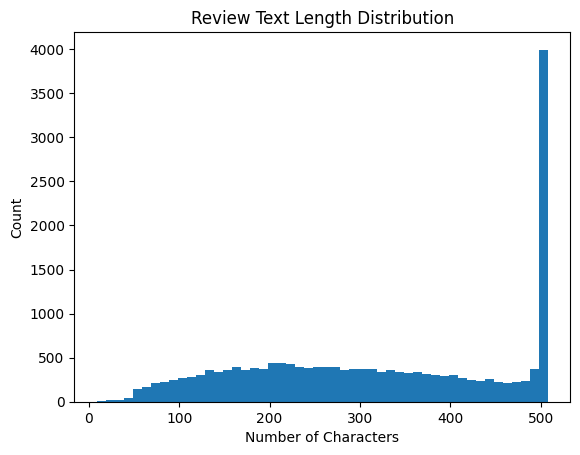

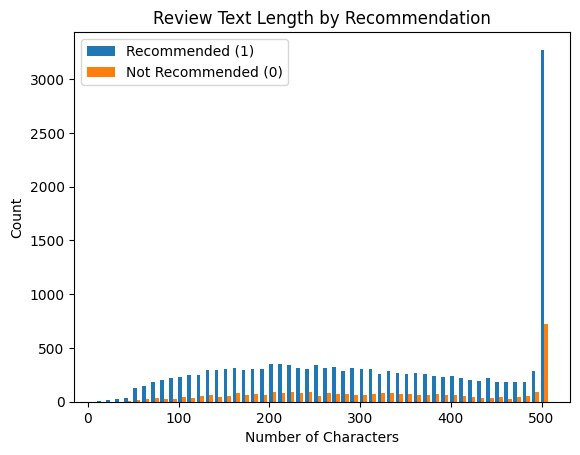

Review length summary by target:


,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,3389.0,327.539687,135.715768,20.0,214.0,327.0,480.0,508.0
1,15053.0,318.289710,143.270140,9.0,197.0,315.0,477.0,508.0


In [9]:
# Review text length analysis

text = df["Review Text"].fillna("").astype(str)
df["_review_len"] = text.str.len()

plt.figure()
plt.hist(df["_review_len"], bins=50)
plt.title("Review Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.show()

len_1 = df.loc[df["Recommended IND"] == 1, "_review_len"]
len_0 = df.loc[df["Recommended IND"] == 0, "_review_len"]

plt.figure()
plt.hist([len_1, len_0], bins=50, label=["Recommended (1)", "Not Recommended (0)"])
plt.title("Review Text Length by Recommendation")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Review length summary by target:")
display(df.groupby("Recommended IND")["_review_len"].describe())

The second visualization compares review text length between recommended and non-recommended products. The distributions for both classes are quite similar, indicating that customers tend to write reviews of comparable length regardless of whether they recommend the product or not.

## Building Pipeline

Create a single end-to-end pipeline that preprocesses numeric/categorical/text features and trains a classifier.

In [17]:
# BUILDING PIPELINE
# We build a full scikit-learn Pipeline that:
# 1) imputes/scales numeric features
# 2) imputes/one-hot encodes categorical features
# 3) vectorizes text using TF-IDF
# 4) trains a classifier (Logistic Regression)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler ,FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

Specify which columns are numeric, categorical, and text.

In [11]:
# Define feature groups

TARGET_COL = "Recommended IND"

# Numeric features
NUMERIC_COLS = ["Age", "Positive Feedback Count"]

# Categorical features
CATEGORICAL_COLS = ["Division Name", "Department Name", "Class Name"]

# Text feature (main signal)
TEXT_COL = "Review Text"


Create a lightweight text preprocessor for normalizing review text before vectorization.

In [12]:
# Text preprocessing function for TF-IDF
# Keeps it simple and fast: lowercase + remove non-letters + collapse spaces.

import re

def basic_text_cleaner(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z\s]", " ", s)   # keep letters/spaces (English dataset)
    s = re.sub(r"\s+", " ", s).strip()
    return s

Assemble ColumnTransformer + classifier into one pipeline

In [18]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Text pipeline (FIX: use FunctionTransformer instead of SimpleImputer)
text_transformer = Pipeline(steps=[
    ("fillna", FunctionTransformer(lambda x: x.fillna("").astype(str), validate=False)),
    ("tfidf", TfidfVectorizer(
        preprocessor=basic_text_cleaner,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_COLS),
        ("cat", categorical_transformer, CATEGORICAL_COLS),
        ("txt", text_transformer, TEXT_COL)  # keep as string so TF-IDF receives a 1D Series
    ],
    remainder="drop"
)

# Classifier
clf = LogisticRegression(max_iter=2000, solver="liblinear")

# Full pipeline
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", clf)
])

pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Division Name',
                                                   'Department Name',
                                                   'Class Name']),
                                                 ('txt',
                                                  Pipeline(steps=[('fillna',
                                                                   FunctionTransformer(func=<function <lambda> at 0x0000017FBA3A3E20>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_df=0.95,
                                                                                   min_df=3,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   preprocessor=<function basic_text_cleaner at 0x0000017FB89F0180>,
                                                                                   stop_words='english'))]),
                                                  'Review Text')])),
                ('clf', LogisticRegression(max_iter=2000, solver='liblinear'))])

## Training Pipeline

Train the pipeline using the provided train split and evaluate it on the test split.

In [14]:
# TRAINING PIPELINE
# Fit the full pipeline and evaluate on the held-out test set.

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Train the model and generate classification metrics + confusion matrix.

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.7692    0.4281    0.5501       327
           1     0.8876    0.9723    0.9280      1518

    accuracy                         0.8759      1845
   macro avg     0.8284    0.7002    0.7391      1845
weighted avg     0.8666    0.8759    0.8610      1845



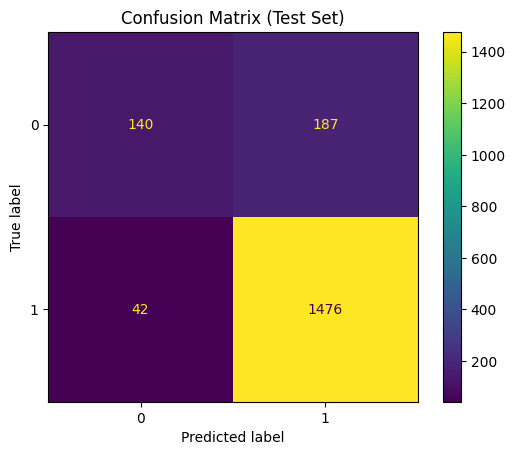

In [19]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()

The classification report and confusion matrix summarize the performance of the trained machine learning pipeline on the test dataset.

The overall accuracy of the model is approximately 87.6%, indicating that the model correctly predicts whether a customer recommends a product in the majority of cases. However, because the dataset is class imbalanced (most reviews recommend the product), accuracy alone is not sufficient to fully evaluate the model.

Looking at the class-specific metrics, the model performs very well in predicting recommended products (class 1). The recall for this class is 0.97, meaning that the model successfully identifies the vast majority of reviews that recommend a product. This is also reflected in the confusion matrix, where 1476 recommended reviews are correctly classified.

However, the model performs less effectively in identifying non-recommended products (class 0). The recall for this class is only 0.43, meaning that more than half of the non-recommended reviews are incorrectly classified as recommended. In the confusion matrix, 187 reviews that were actually not recommended were predicted as recommended.

This behavior is expected given the strong class imbalance in the dataset, where recommended reviews dominate the data. As a result, the model tends to favor predicting the majority class.

Despite this limitation, the model still provides strong predictive performance overall, particularly in identifying recommended products. Future improvements could include techniques such as class balancing, adjusting class weights, or experimenting with alternative models to improve the detection of non-recommended products.

## Fine-Tuning Pipeline

Use GridSearchCV with cross-validation to tune TF-IDF and Logistic Regression hyperparameters inside the pipeline

In [20]:
# FINE-TUNING PIPELINE
# Use GridSearchCV to tune:
# - TF-IDF parameters (ngram_range, min_df, max_df)
# - LogisticRegression regularization strength (C)
# - class_weight for imbalance robustness

from sklearn.model_selection import GridSearchCV, StratifiedKFold

Search for the best pipeline configuration using cross-validation on the training set.

In [21]:
# Define CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

param_grid = {
    "preprocess__txt__tfidf__ngram_range": [(1, 1), (1, 2)],
    "preprocess__txt__tfidf__min_df": [2, 3, 5],
    "preprocess__txt__tfidf__max_df": [0.9, 0.95],
    "clf__C": [0.3, 1.0, 3.0],
    "clf__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",           # good default for classification with potential imbalance
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV score (F1):", grid.best_score_)
print("Best parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV score (F1): 0.9339020923075084
Best parameters:
{'clf__C': 3.0, 'clf__class_weight': None, 'preprocess__txt__tfidf__max_df': 0.9, 'preprocess__txt__tfidf__min_df': 3, 'preprocess__txt__tfidf__ngram_range': (1, 2)}


Evaluate the best estimator from GridSearchCV on the held-out test set

Classification Report (Test Set) - Tuned Model:
              precision    recall  f1-score   support

           0     0.7469    0.5596    0.6399       327
           1     0.9100    0.9592    0.9339      1518

    accuracy                         0.8883      1845
   macro avg     0.8285    0.7594    0.7869      1845
weighted avg     0.8811    0.8883    0.8818      1845



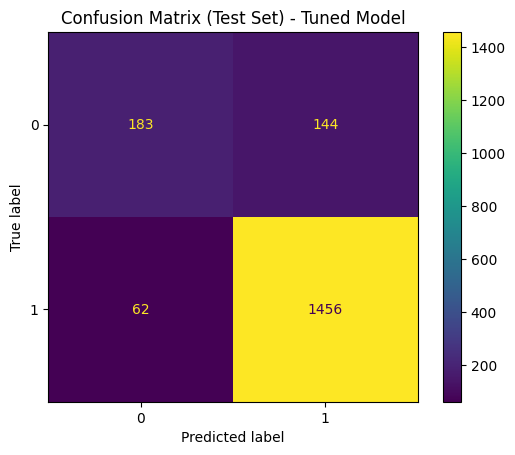

In [22]:
# Evaluate best model on test set

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Classification Report (Test Set) - Tuned Model:")
print(classification_report(y_test, y_pred_best, digits=4))

cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best)
disp.plot()
plt.title("Confusion Matrix (Test Set) - Tuned Model")
plt.show()

The classification report and confusion matrix show the performance of the fine-tuned machine learning pipeline on the test dataset. Compared to the baseline model, the tuned model demonstrates a notable improvement in overall performance.

The overall accuracy increased from approximately 87.6% to 88.8%, indicating that the model became slightly more accurate after hyperparameter tuning. More importantly, the performance for the non-recommended class (class 0) improved significantly.

In the baseline model, the recall for class 0 was 0.43, meaning that the model struggled to correctly identify reviews that did not recommend a product. After fine-tuning, the recall for class 0 increased to 0.56, which represents a meaningful improvement in detecting negative recommendations.

This improvement can also be seen in the confusion matrix. The number of correctly classified non-recommended reviews increased from 140 to 183, while the number of misclassified non-recommended reviews decreased from 187 to 144.

For the recommended class (class 1), the model continues to perform very well. Although the recall slightly decreased from 0.97 to 0.96, it still maintains a high level of performance with 1456 correctly classified recommended reviews.

Overall, the tuned model achieves a better balance between detecting recommended and non-recommended products. This suggests that hyperparameter tuning helped the model generalize better and reduce bias toward the majority class.